#Trabalho de Conclusão de Curso
#Especialização em Ciência de Dados
Prof. Eduardo Kugler Viegas<BR>
Alunos: Humberto Pradera e Leonardo Rocha

Experimentos para subsidiar a escrita do artigo<BR>

Utilizamos a versão NetFlow v3 Datasets

Visualização dos gráficos e experimento crossdataset

# Preâmbulo

In [2]:
# Controle de alguns experimentos
QUANTIDADE_MINIMA_CLASSE = 1000
HIGIENIZAR_DATASETS = True
BALANCEAR_DATASETS = True
TEST_SIZE = 0.2

DATA_RESULTADOS = "2025-12-11 200"

In [3]:
#constantes com a definição dos logs
LOG_DIR = f'/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/{DATA_RESULTADOS}/'
LOG_EXECUCAO = 'exec.txt'
LOG_CHECKPOINT = 'checkpoint.pkl'
LOG_FINAL = 'final.pkl'

# Imports, variáveis e funções gerais

In [ ]:
#!pip install tabulate
!pip install fastai
!pip install tensorflow

In [ ]:
#Bibliotecas
import numpy as np
import pandas as pd
import copy #copiar o modelo em memória

import gc

#from tabulate import tabulate  #print de tabela
import itertools #usado na formatação da matriz de confusão


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

#shrink memory dataset
from fastai.tabular.core import df_shrink

#CNN/MLP
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense,  Dropout
from tensorflow.keras.models import Model, Sequential

from google.colab import drive
import math
from time import time as time2
import datetime
#import time

# Para plotagem 3D
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
# Variavel que será redefinida posteriormente
attack_categories = ['Benigno', 'Ataque']

In [ ]:
lista_campos_excluir = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT', 'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
                        'DNS_QUERY_ID', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'MIN_TTL', 'MAX_TTL']
lista_campos_verif = ['SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES']

In [ ]:
#Formata um número em bytes para Megabytes
def format_megabytes(size_in_bytes):
  if size_in_bytes is None:
    return "N/A"
  size_in_mb = size_in_bytes / (1024 * 1024)
  return f"{size_in_mb:.2f} MB"


In [ ]:
def balacear_dataset(pdf):

  if not BALANCEAR_DATASETS:
    print("- Dataset não será balanceado")
    return pdf

  attack_counts = pdf['Attack'].value_counts()
  print("- attack_counts:",attack_counts,"\n")

  min_attack_count = attack_counts[attack_counts.index != 'Benign'].min()
  print("min_attack_count:",min_attack_count)

  benign_count = attack_counts['Benign']
  print("benign_count:", benign_count)

  # Calcula o valor alvo para as classes maliciosas
  target_non_benign_count = min(min_attack_count, benign_count // (len(attack_counts) - 1))
  print("- Quantidade inicial mínima para cada classe de ataque:",target_non_benign_count)

  if target_non_benign_count<QUANTIDADE_MINIMA_CLASSE:
    print(f"-- Então a quantidade inicial mínima é menor que {QUANTIDADE_MINIMA_CLASSE}. O Dataset terá problema no balanceamento.")
    # Se a quantidade inicial or menor que 1000, então teremos um Dataset balanceado com muito poucos casos.
    # Para evitar isto, busco a classe que possua menor representação que tenha quantidade de ocorrências maior que 1000
    # Pego a totalização por tipo de ataque
    vc = pdf['Attack'].value_counts()
    # Filtro de quantidade mínima, estipulada pelo professor como 1000
    vc1k = vc[vc>QUANTIDADE_MINIMA_CLASSE]
    # Pego o último valor, que deve ser o menor valor superior a 1000
    target_non_benign_count = vc1k.tail(1).values[0]
    print("-- Novo valor mínimo encontrado:",target_non_benign_count)

  # De fato faz o balanceamento
  balanced_dfs = []
  for attack_type in attack_counts.index:
    if attack_type == 'Benign':
      balanced_dfs.append(pdf[pdf['Attack'] == 'Benign'].sample(min(benign_count, target_non_benign_count * (len(attack_counts) - 1)), random_state=42))
    else:
      balanced_dfs.append(pdf[pdf['Attack'] == attack_type].sample(min(attack_counts[attack_type], target_non_benign_count), random_state=42))

  alldf = pd.concat(balanced_dfs)

  print("\nResultado do balanceamento:")
  attack_counts = alldf['Attack'].value_counts()
  print("- attack_counts:",attack_counts,"\n")

  return alldf

In [ ]:
def higienizar_dataset(pdf):

  if not HIGIENIZAR_DATASETS:
    print("- Dataset não será higienizado")
    return

  qtd_ini = len(pdf)
  print("- Tamanho original do Dataset: {:,}".format(qtd_ini))

  # Drop rows where SRC_TO_DST_SECOND_BYTES or DST_TO_SRC_SECOND_BYTES have infinite values or values > np.finfo(np.float64).max
  print("- Removendo registros com campos com valor infinito ou superior a np.float64")
  for col in lista_campos_verif:
    pdf.drop(pdf[np.isinf(pdf[col])].index, inplace=True)
    pdf.drop(pdf[pdf[col] > np.finfo(np.float64).max].index, inplace=True)

  #retira registros com campos NA
  print("- Removendo registros com campos NA")
  pdf.dropna(subset=['SRC_TO_DST_SECOND_BYTES'], inplace=True)

  # verificando se há linhas duplicadas
  qtd_duplicadas = pdf.duplicated().sum()

  if qtd_duplicadas > 0:
    print("- Encontrados {:,} registros duplicados".format(qtd_duplicadas))
    # retirando as linhas duplicadas
    pdf.drop_duplicates(inplace=True)
    pdf.reset_index(inplace=True, drop=True)

  qtd_fim = len(pdf)
  print("- Ao total, foram eliminados {:,} registros".format(qtd_ini-qtd_fim))
  print("- Tamanho final {:,}".format(qtd_fim))

In [ ]:
# Instalação das fontes Latin Modern no Colab
'''
!apt-get install -qq texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

# Limpa o cache de fontes do matplotlib para reconhecer as novas fontes
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'mathtext.fontset': 'cm',
    'text.usetex': True  # Habilita LaTeX para renderização de texto
})
'''

"\n!apt-get install -qq texlive-fonts-recommended texlive-fonts-extra cm-super dvipng\n\n# Limpa o cache de fontes do matplotlib para reconhecer as novas fontes\nimport matplotlib.font_manager as fm\nfm._load_fontmanager(try_read_cache=False)\n\nplt.rcParams.update({\n    'font.family': 'serif',\n    'font.serif': ['Computer Modern Roman'],\n    'font.size': 12,\n    'axes.titlesize': 14,\n    'axes.labelsize': 12,\n    'xtick.labelsize': 10,\n    'ytick.labelsize': 10,\n    'mathtext.fontset': 'cm',\n    'text.usetex': True  # Habilita LaTeX para renderização de texto\n})\n"

# Datasets

In [6]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [ ]:
df_url = []
df = []

df_url.append('#')
df_url.append('/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Dataset/NF-ToN-IoT-v3/data/NF-ToN-IoT-v3.csv')
df_url.append('#')
df_url.append('#')

tamanho_antes = 0
tamanho_depois = 0

#limita a quantidade de registros a carregar ao mesmo tempo em memóris
#para permitir uma máquina com mesmo tempo processar os Datasets
chunk_size = 4000000
chunk_resultset = []

#loop carregando os datasets
for index, d in enumerate(df_url):
  #carrega
  print("\n--- Dataset",index+1,'---')
  if d == '#':
    print("Dataset desativado para processamento.")
    # Para manter compatibilidade com o restante do código, adiciona um DataFrame vazio
    df.append(pd.DataFrame())
    continue

  #cria um iterator para ler o arquivo em pedaços
  chunk_iter = pd.read_csv(d, chunksize=chunk_size)

  chunk_number = 0
  for chunk in chunk_iter:
    chunk_number += 1
    print(f"---- Processando chunk {chunk_number} ----")
    print("- Lidas {:,} linhas.".format(len(chunk)))

    tamanho_memoria_ds = chunk.memory_usage(deep=True).sum()
    print("Chunk carregado:",format_megabytes(tamanho_memoria_ds))
    tamanho_antes += tamanho_memoria_ds

    #elimina colunas desnecessárias
    chunk = chunk.drop(lista_campos_excluir, axis=1)
    print("Campos desnecessários removidos.")

    #higieniza dataset
    higienizar_dataset(chunk)
    print("Chunk higienizado.")

    chunk_resultset.append(chunk)
    gc.collect()
    print("Garbage collector invocado para o chunk")

  #unifica o que restou dos chunks
  mydf = pd.concat(chunk_resultset)
  chunk_resultset.clear()

  #Só para garantir que não teremos duplicados resultantes da união dos chunks
  higienizar_dataset(mydf)
  print("Dataset higienizado.")

  #balenceia o dataset
  mydf = balacear_dataset(mydf)
  print("Dataset balanceado.")

  #reduz o tamanho
  mydf = df_shrink(mydf)
  print("Dataset reduzido.")
  print("- Tamanho atual: {:,} linhas.".format(len(mydf)))

  gc.collect()
  print("Garbage Collector invocado para o final.")

  tamanho_memoria_ds = mydf.memory_usage(deep=True).sum()
  tamanho_depois += tamanho_memoria_ds

  #anexa na lista de datasets
  df.append(mydf)

print(" ")
print("Tamanho original dos Datasets:",format_megabytes(tamanho_antes))
print("Tamanho final dos Datasets:",format_megabytes(tamanho_depois))


--- Dataset 1 ---
Dataset desativado para processamento.

--- Dataset 2 ---
---- Processando chunk 1 ----
- Lidas 4,000,000 linhas.
Chunk carregado: 2266.09 MB
Campos desnecessários removidos.
- Tamanho original do Dataset: 4,000,000
- Removendo registros com campos com valor infinito ou superior a np.float64
- Removendo registros com campos NA
- Encontrados 3,902,332 registros duplicados
- Ao total, foram eliminados 3,902,332 registros
- Tamanho final 97,668
Chunk higienizado.
Garbage collector invocado para o chunk
---- Processando chunk 2 ----
- Lidas 4,000,000 linhas.
Chunk carregado: 2266.14 MB
Campos desnecessários removidos.
- Tamanho original do Dataset: 4,000,000
- Removendo registros com campos com valor infinito ou superior a np.float64
- Removendo registros com campos NA
- Encontrados 3,867,203 registros duplicados
- Ao total, foram eliminados 3,867,203 registros
- Tamanho final 132,797
Chunk higienizado.
Garbage collector invocado para o chunk
---- Processando chunk 3 ---

In [ ]:
print("Linhas lidas dos DS:")
for i, d in enumerate(df):
  print(f"DS{i+1}:",len(d))


Linhas lidas dos DS:
DS1: 0
DS2: 50616
DS3: 0
DS4: 0


## Definição dos conjuntos de dados

### Conjunto de dados DS2

In [ ]:
X2 = df[1].drop(['Attack', 'Label'], axis=1)
y2 = df[1].loc[:, 'Label']

In [ ]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x2_train, x2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=TEST_SIZE, random_state=42, stratify=y2)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x2_train_scaled = scaler.fit_transform(x2_train)
x2_test_scaled = scaler.transform(x2_test)

### Conjunto de dados DS3

In [ ]:
#X3 = df[2].drop(['Attack', 'Label'], axis=1)
#y3 = df[2].loc[:, 'Label']

In [ ]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
#x3_train, x3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=TEST_SIZE, random_state=42, stratify=y3)

# já prepara a normalização para quando precisar
#scaler = StandardScaler()
#x3_train_scaled = scaler.fit_transform(x3_train)
#x3_test_scaled = scaler.transform(x3_test)

### Conjunto de dados DS4

In [ ]:
#X4 = df[3].drop(['Attack', 'Label'], axis=1)
#y4 = df[3].loc[:, 'Label']

In [ ]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
#x4_train, x4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=TEST_SIZE, random_state=42, stratify=y4)

# já prepara a normalização para quando precisar
#scaler = StandardScaler()
#x4_train_scaled = scaler.fit_transform(x4_train)
#x4_test_scaled = scaler.transform(x4_test)

## Função que cria um modelo

In [ ]:
def cria_modelo(pShape, pOutput=True, pQtdNeurons=5, pQtdCamadas=1):
  # Validacao dos parâmetros
  if (pQtdCamadas < 1) or (pQtdCamadas > 9):
    raise ValueError("O número de camadas deve ser maior do que 0 e inferior a 10.")

  ## Modelo base
  modelo = Sequential([
      # Camada de Entrada
      Input(shape=(pShape,))
  ])

  # Adiciona camadas ocultas baseadas em pQtdCamadas
  # Acrescento Dropout também
  for _ in range(pQtdCamadas):
      modelo.add(Dense(2**pQtdNeurons, activation='relu'))
      # Dropout para prevenir overfitting
      modelo.add(Dropout(0.1))

  # Camada de saída
  modelo.add(Dense(2, activation='softmax'))

  # Arquitetura
  if pOutput:
    modelo.summary()
    print(f"Modelo criado com {pQtdCamadas} camadas ocultas e {2**pQtdNeurons} neurônios por camada.")
    print(f"Shape de entrada: {pShape}")

  ## Compilando o modelo
  if pOutput:
    print("\nCompilando modelo...")

  modelo.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      #loss='binary_crossentropy'
      metrics=['accuracy']
  )

  if pOutput:
    print(f"Learning rate: {modelo.optimizer.learning_rate.numpy()}")
    print("Compilação completa.\n")

  return modelo

# MultiObjetivo

In [ ]:
!pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.1 MB/s eta 0:00:00


In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.core.problem import Problem
from pymoo.core.sampling import Sampling

from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.callback import Callback

import os
import pickle


In [ ]:
#! pip show tensorflow
#! pip show scikit-learn
#! pip show pymoo
#! python --version

In [ ]:
#isto significa uma quantidade de
print(f"Quantidade de possibilidades de qualquer número de features: {2**len(X2.columns):,}")
print(f"Quantidade de possibilidades de 40 features pegando 17 a cada vez: {math.comb(40, 17):,}")
print(f"Quantidade de possibilidades de 40 features pegando 05 a cada vez: {math.comb(40,  5):,}")
print(f"Quantidade de possibilidades de 40 features pegando 03 a cada vez: {math.comb(40,  3):,}")

Quantidade de possibilidades de qualquer número de features: 1,099,511,627,776
Quantidade de possibilidades de 40 features pegando 17 a cada vez: 88,732,378,800
Quantidade de possibilidades de 40 features pegando 05 a cada vez: 658,008
Quantidade de possibilidades de 40 features pegando 03 a cada vez: 9,880


##### Código do Pymoo

In [ ]:
class CustomFeatureSampling(Sampling):
    """
    Sampling customizado que inicia a população com diferentes quantidades de features.
    Garante diversidade na quantidade de features selecionadas.
    """
    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, problem.n_var), dtype=int)

        for i in range(n_samples):
            #sampling do pymoo
            # Para cada uma das 40 features independentemente:
            #feature[i] = np.random.randint(0, 2)  # 0 ou 1, com 50% de chance cada
            #Número de features | Probabilidade
            #0                  | 0.00000009%  (praticamente impossível)
            #5                  | 0.03%        (muito raro)
            #10                 | 3.5%
            #15                 | 12%
            #20                 | 18%          (PICO - mais provável)
            #25                 | 12%
            #30                 | 3.5%
            #35                 | 0.03%        (muito raro)
            #40                 | 0.00000009%  (praticamente impossível)

            #Huang & Wang (2006) - "Genetic Algorithm with Adaptive Elitist-population"
            #Recomendam: sampling uniforme em quantidades de features

            #Kabir et al. (2012) - "A New Hybrid AntTree for Feature Selection"
            #Usam: distribuição uniforme entre 10% e 90% das features

            #Xue et al. (2016) - PSO para feature selection
            #Inicialização: uniforme entre valores extremos

            # Nos testes anteriores, o limite inferior de features selecionadas nas soluções ótimas encontradas era 17
            # Por outro lado, 90% de 40 é 36, o que é um valor alto para este problema.
            # Features (primeiras 40 variáveis): seleciona aleatoriamente entre 17 e 35 features
            # Teremos uma diversidade maior de soluções iniciais  distribuída igualmente entre as soluções
            # (5,26% para cada quantidade de features entre 17 e 35)
            n_features_to_select = np.random.randint(17, 36)

            selected_indices = np.random.choice(40, n_features_to_select, replace=False)
            X[i, selected_indices] = 1

            # Neurônios (variável 40): entre 2 e 9
            X[i, 40] = np.random.randint(2, 10)

            # Camadas (variável 41): entre 1 e 5
            X[i, 41] = np.random.randint(1, 6)

        return X



###############################################################################################
# Custom Callback for saving checkpoints
###############################################################################################
class CheckpointCallback(Callback):

    def __init__(self, filename="checkpoint.pkl", verbose=False):
        super().__init__()
        self.filename = filename
        self.verbose = verbose
        self.n_eval = 0

    def notify(self, algorithm):
        # Save the algorithm state
        s = f"{self.filename}_{algorithm.n_gen}.pkl"
        with open(s, 'wb') as f:
            pickle.dump(algorithm, f)

        if self.verbose:
            print(f"Checkpoint saved at generation {algorithm.n_gen} to {s}")

        # reduz o consumo de memória a cada geração
        gc.collect()
        if self.verbose:
            print(f"Garbage collection completed at generation {algorithm.n_gen}")


def Minimize(problem):

    #inicialização padrão, com poucas features
    #amostragem_customizada = SamplingComFeaturesFixas(n_features_para_selecionar=5)

    # Define the path for saving and loading the checkpoint
    checkpoint_path = LOG_DIR + LOG_CHECKPOINT

    # Create the checkpoint callback
    checkpoint_callback = CheckpointCallback(filename=checkpoint_path, verbose=True)

    # Check if a checkpoint exists and load it
    if os.path.exists(f"{checkpoint_path}.pkl"):
        print(f"Loading checkpoint from: {checkpoint_path}.pkl")

        with open(f"{checkpoint_path}.pkl", 'rb') as f:
            algorithm = pickle.load(f)
        print(f"Resuming from generation {algorithm.n_gen}")

        # Continua otimização
        res = minimize(problem,
                       algorithm, # passa o algoritmo carregado
                       seed=42,   # mantém o mesmo seed original
                       save_history=True,
                       verbose=True,
                       termination=('n_gen', 100),  # continua até o número de gerações chega a 100
                       callback=checkpoint_callback # callback para gravação
                       )
    else:
        print(f"No checkpoint found with name {checkpoint_path}.pkl. Starting new optimization.")

        algorithm = NSGA2(pop_size=200
                          , sampling=CustomFeatureSampling()
                          , crossover=UniformCrossover(prob=0.9)
                          #, mutation=BitflipMutation(prob=0.05)  # 5% de chance de flipar cada bit RUIM PARA ESTE PROBLEMA
                          )
        #print(f"Algorithm Crossover: {algorithm.mating.crossover}")
        #print(f"Algorithm Mutação: {algorithm.mating.mutation}")

        res = minimize(problem,
                       algorithm,
                       seed=42,
                       save_history=True,
                       verbose=True,
                       termination=('n_gen', 100),
                       callback=checkpoint_callback # callback para gravação
                       )

    # Save the final result
    final_result_path = LOG_DIR + LOG_FINAL
    os.makedirs(os.path.dirname(final_result_path), exist_ok=True)

    with open(final_result_path, 'wb') as f:
        pickle.dump(res, f)
    print(f"Final result saved to: {final_result_path}")


    return res



###############################################################################################
# Classe do problema a ser resolvido
###############################################################################################
class NetFlowProblem(ElementwiseProblem): #ElementWise é orientado a objetos

    def is_to_delete_feature(self, prob):
        return prob == 0

    def adjust_features(self, x, X_features):

        delete_indices = [i for i in range(len(x)) if self.is_to_delete_feature(x[i])]

        cols_to_delete = X_features.columns[delete_indices]
        X_features = X_features.drop(columns=cols_to_delete)

        return X_features

    def create_and_train_model(self, pX, py, pQtdNeurons, pQtdCamadas):
        # Dados: separando da base original uma parte para teste
        x_train, x_test, y_train, y_test = train_test_split(pX, py, test_size=0.2, random_state=42, stratify=py)

        # Dados: normalização
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        # Cria modelo
        mymodel = cria_modelo(pShape=x_train_scaled.shape[1],
                              pOutput=False,
                              pQtdNeurons=pQtdNeurons,
                              pQtdCamadas=pQtdCamadas)

        # Treina o modelo
        history = mymodel.fit(
          x_train_scaled,
          y_train,
          epochs=15,
          batch_size=BATCH_SIZE,
          validation_data=(x_test_scaled, y_test),
          #callbacks=[mc_accm], # desativei a callback para aumentar a velocidade. Resultado: não alterou tanto...
          verbose=0             # progress bar
        )

        # Libera a memória dos dados de treino/teste que não são mais necessários
        del x_train, x_test, y_train, y_test, x_train_scaled, x_test_scaled, scaler, history
        gc.collect()

        return mymodel


    def get_predicted_class(self, pX, py, modelAll):

        # Separando da base original uma parte para validação. Aqui eu chamarei de teste
        x_train, x_test, y_train, y_test = train_test_split(pX, py, test_size=0.2, random_state=42, stratify=py)

        # normalização
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        # Executa a predição no conjunto de dados de teste
        predictions_prob = modelAll.predict(x_test_scaled, verbose=0 )
        predictions = (predictions_prob > 0.5).astype("int32").flatten()

        #marca para o garbage collector remover da memória a fim de conter a expansão do consumo
        del x_train, x_test, y_train, x_train_scaled, x_test_scaled, predictions_prob #, mc_accm, fpm
        gc.collect()


        return predictions, y_test


    def evaluate_model_f1(self,pX
                              ,py
                              ,modelAll
                          ):
        # Executa a predição no conjunto de dados passado (algum dataset de teste)
        y_test_predict, y_test_true = self.get_predicted_class(pX, py, modelAll)
        # Calcula o F1 Score
        #f1_test = f1_score(y_true=y_test_true, y_pred=y_test_predict)

        # Calcula a matriz de confusão para obter TN, FP, FN, TP
        try:
            tn, fp, fn, tp = confusion_matrix(y_true=y_test_true, y_pred=y_test_predict).ravel()
            # Calcula TPR (True Positive Rate ou Recall) e TNR (True Negative Rate ou Specificity)
            # Adiciona uma pequena constante (epsilon) para evitar divisão por zero
            epsilon = 1e-7
            tpr = tp / (tp + fn + epsilon)
            tnr = tn / (tn + fp + epsilon)

            # Calcula o F1 Score com base em TP, FP e FN
            precision = tp / (tp + fp + epsilon)
            recall = tp / (tp + fn + epsilon)
            f1_test = 2 * (precision * recall) / (precision + recall + epsilon)
        except ValueError:
            # Caso a predição contenha apenas uma classe, o ravel() falhará.
            tpr, tnr, f1_test = 0.0, 0.0, 0.0

        del y_test_predict, y_test_true

        #retorno 1-, porque queremos minimizar o valor de comparação
        return (1 - f1_test), tpr, tnr



    def __init__(self, *args):

        # Define os limites inferiores (xl) e superiores (xu) para as 42 variáveis inteiras.
        # 40 variáveis para seleção de features (0 ou 1)
        # 1 variável para número de neurônios (2 a 9)
        # 1 variável para número de camadas (1 a 5)
        xl = np.array([0] * 40 + [2, 1])
        xu = np.array([1] * 40 + [9, 5])

        self.contagem = 0

        #Variaveis: 40 features + neuronios
        super().__init__(
            n_var=42,                               # 42 variáveis no total
            xl=xl,                                  # Limites inferiores
            xu=xu,                                  # Limites superiores
            vtype=int,                              # Define que todas as variáveis são inteiras
            n_obj=3,                                # Número de objetivos (menor 1-F1 DS1, DS2, DS3)
            n_ieq_constr=3                          # restrição de desigualdade
        )



    def _evaluate(self, x, out, *args, **kwargs):
      #variaveis
      f1_2 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      f1_3 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      f1_4 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      tpr_2, tnr_2 = 0.0, 0.0
      tpr_3, tnr_3 = 0.0, 0.0
      tpr_4, tnr_4 = 0.0, 0.0
      qtd_features = 40        # O valor será determinado posteriormente
      num_neurons = int(x[-2]) # O penúltimo elemento de x é a quantidade de neurônios
      qtd_camadas = int(x[-1]) # O último elemento de x é a quantidade de camadas

      self.contagem += 1

      t0 = time2()
      #print("Current x:", x, end="") # esse x é o vetor que indica quais campos devem ser ativados ou não

      # Obtém o algoritmo do Pymoo e o número da avaliação atual a partir dos kwargs
      #algorithm = kwargs.get("algorithm")
      #n_eval = algorithm.evaluator.n_eval if algorithm else 0
      print(f"Avaliação {self.contagem:05d}", end='')

      # Extrai a parte de seleção de features do vetor x
      # Todas as posições exceto as duas últimas
      x_features_selection = x[:-2]

      # Dataset All #################
      # reinicializa os vetores, com os valores originais de definição do Dataset
      X_tmp = XAll.copy()
      y_tmp = yAll.copy()

      #acerta os campos do dataset
      X_tmp = self.adjust_features(x_features_selection, X_tmp)
      qtd_features = len(X_tmp.columns)

      parametros_validos = True

      # A restrição para o número de camadas é ser entre 1 e 5.
      if ((qtd_camadas<1) or (qtd_camadas>5)):
        print(", Número incorreto de camadas alcançado(<1 ou >5)", end="")
        parametros_validos = False

      if ((qtd_features<2) or (num_neurons<2)):
        print(", Número insuficiente de features/neurônios alcançado(<2)", end="")
        parametros_validos = False

      if ((num_neurons>9)):
        print(", Número de neurônios fora do limite superior a 9", end="")
        parametros_validos = False

      if parametros_validos:
        # Treino o modelo no Dataset All e avalio nos outros datasets
        # Treino no All
        modelAll = self.create_and_train_model(X_tmp, y_tmp, num_neurons, qtd_camadas)

        # Dataset 2 ################
        X_tmp = X2.copy()
        y_tmp = y2.copy()
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        f1_2, tpr_2, tnr_2  = self.evaluate_model_f1(X_tmp, y_tmp, modelAll)

        # Dataset 3 ################
        X_tmp = X3.copy()
        y_tmp = y3.copy()
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        f1_3, tpr_3, tnr_3  = self.evaluate_model_f1(X_tmp, y_tmp, modelAll)

        # Dataset 4 ################
        X_tmp = X4.copy()
        y_tmp = y4.copy()
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        f1_4, tpr_4, tnr_4  = self.evaluate_model_f1(X_tmp, y_tmp, modelAll)

        # Limpa o modelo e a sessão do Keras imediatamente
        #del self.modelAll
        #self.modelAll = None
        if modelAll is not None:
          for layer in modelAll.layers:  # Deleta cada camada
            del layer
          del modelAll


        tf.keras.backend.clear_session()

        # Força limpeza de memória da GPU se disponível
        if tf.config.list_physical_devices('GPU'):
            try:
                tf.compat.v1.reset_default_graph()
            except:
                pass

      # Cálculo de tempo
      t1 = (time2() - t0)
      print(f", duração: {t1:.2f}", end="")


      # --- CÁLCULO DA RESTRIÇÃO ---
      # A restrição é haver ao menos o valor 2 nos campos features e neuronios
      # Então a fórmula é `2 - qtd_features`.
      # Um valor > 0 significa que a restrição foi violada (qtd_features < 2).
      # Um valor <= 0 significa que a restrição foi satisfeita (qtd_features >= 2).
      g_features =  2 - qtd_features
      # O mesmo para os neurônios, que não podem ser inferior a 2
      g_neuronios = 2 - num_neurons
      # O mesmo para o mínimo de camadas, que não podem ser inferior a 1
      # e também nao podem ser maior que 5
      if qtd_camadas <= 1:
        g_camadas = 1 - qtd_camadas
      else:
        if qtd_camadas > 5:
          g_camadas = qtd_camadas
        else:
          g_camadas = qtd_camadas - 5

      out["G"] = [g_features, g_neuronios, g_camadas]

      # Os objetivos são: qtd_features, 1-F1 DS1, 1-F1 DS2, 1-F1 DS3, num_neurons
      out["F"] = [f1_2, f1_3, f1_4]

      print(f", qtd feat.:{qtd_features}, camadas:{qtd_camadas}, neurônios:{num_neurons} | 1-F1 DS2:{f1_2:.4f}, DS3:{f1_3:.4f}, DS4:{f1_4:.4f}")

      # gravacao de log para avaliação posterior
      str_log = f'{datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}, {self.contagem:05d}, {qtd_features}, {f1_2:.4f}, {f1_3:.4f}, {f1_4:.4f}, {num_neurons}, {t1:.2f}, {qtd_camadas}, {tpr_2:.4f}, {tnr_2:.4f}, {tpr_3:.4f}, {tnr_3:.4f}, {tpr_4:.4f}, {tnr_4:.4f}'

      # marca para o garbage collector remover da memória a fim de conter a expansão do consumo
      #self.modelAll = None

      with open(LOG_DIR+LOG_EXECUCAO, 'a') as f:
        f.write(str_log + '\n')
        f.flush()

      del X_tmp, y_tmp, f1_3, tpr_3, tnr_3, f1_2, tpr_2, tnr_2, f1_4, tpr_4, tnr_4, x_features_selection
      del parametros_validos, g_camadas, g_features, g_neuronios, num_neurons, qtd_camadas, qtd_features, t0, t1
      del str_log

      # Força garbage collection agressivo (múltiplas gerações)
      gc.collect()
      gc.collect()
      #gc.collect()

################################################ Fim da classe do problema ##########################################################



In [ ]:
problem = NetFlowProblem()

### Execução do pymoo

In [ ]:
#res_dt = Minimize(problem)

### Leitura da gravação final

In [ ]:
import pickle

# Define o caminho do arquivo salvo
load_path = LOG_DIR+LOG_FINAL

# Carrega o objeto res_dt do arquivo
with open(load_path, 'rb') as f:
    loaded_res_dt = pickle.load(f)

print(f"Objeto res_dt carregado com sucesso de: {load_path}")


Objeto res_dt carregado com sucesso de: /content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-12-11 200/final.pkl


# Resultados

### Lista das soluções

In [ ]:
import os
import pickle

# Define o caminho do arquivo de resultado final
# O 'load_path' já foi definido anteriormente em 4a9bb366 como LOG_DIR + LOG_FINAL

# Carrega o objeto 'res' (resultado final da otimização) do arquivo
if os.path.exists(load_path):
    with open(load_path, 'rb') as f:
        loaded_res = pickle.load(f)
    print(f"Objeto de resultado final carregado com sucesso de: {load_path}")

    # As soluções e objetivos estão na população final do resultado (loaded_res.pop)
    # Renomeando as variáveis para refletir que são as soluções finais e não um checkpoint
    X_final_pop = loaded_res.pop.get("X")
    F_final_pop = loaded_res.pop.get("F")

    n_solutions, n_variables = X_final_pop.shape
    objectives = F_final_pop

    print(f"\nNúmero de soluções na população final: {n_solutions}")
    print(f"Número de variáveis por solução na população final: {n_variables}")
    #print(f"Objetivos das soluções na população final:\n{objectives}")

else:
    print(f"Arquivo de resultado final não encontrado em: {load_path}")

Objeto de resultado final carregado com sucesso de: /content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-12-11 200/final.pkl

Número de soluções na população final: 200
Número de variáveis por solução na população final: 42


In [ ]:
# Supondo que 'loaded_res_dt' já foi carregado
# loaded_res_dt.X contém todas as soluções encontradas (cada linha é uma solução)
# A forma de loaded_res_dt.X é (número de soluções, número de variáveis)
# O número de variáveis é o número de features originais + 1 (para o número de neurônios)

# Get the actual number of solutions and variables from loaded_res_dt
n_solutions, n_variables = loaded_res_dt.X.shape
n_features = n_variables - 2 # O número de features é o número total de variáveis menos 2

# Obtenha os valores dos objetivos para cada solução
objectives = loaded_res_dt.F

print(f"Número de soluções encontradas: {n_solutions}")
print(f"Número total de features no problema: {n_features}")
print("\nDetalhes para cada solução encontrada:")


# Obtenha os nomes das colunas do DataFrame original (X)
# Certifique-se de que X está disponível no ambiente
#if 'X' in globals() and isinstance(X, pd.DataFrame):
feature_names = X2.columns.tolist()
#else:
#    print("DataFrame 'X' não encontrado. Não é possível mapear os índices de volta para os nomes das features.")
#    feature_names = [f"Feature {i}" for i in range(n_features)] # Crie nomes genéricos se X não estiver disponível



#pega os indices dos melhores
idx_max_ds2 = -1
idx_max_ds3 = -1
idx_max_ds4 = -1
idx_max_avg = -1

vlr_max_ds2 = 0
vlr_max_ds3 = 0
vlr_max_ds4 = 0
vlr_max_avg = 0

vlr_avg_ds2 = 0;
vlr_avg_ds3 = 0;
vlr_avg_ds4 = 0;

for i in range(n_solutions):
    solution = loaded_res_dt.X[i]
    #solution = X_from_checkpoint[i]
    feature_selection_vector = solution[:-2]  # Exclui as últimas colunas (número de neurônios e num camadas)
    num_neurons = int(solution[-2])
    num_camadas = int(solution[-1])

    # Encontra os índices onde o valor é 1 (features selecionadas)
    selected_feature_indices = np.where(feature_selection_vector > 0.5)[0] # Use > 0.5 para acomodar floats

    # Mapeia os índices selecionados de volta para os nomes das features
    selected_features = [feature_names[j] for j in selected_feature_indices]

    # Obtém os valores dos objetivos para a solução atual
    current_objectives = objectives[i]

    print(f"Solução {i+1}:")
    print(f"  Número de Neurônios: {num_neurons}")
    print(f"  Quantidade de Features Selecionadas: {len(selected_features)}")
    print(f"  Features Selecionadas: {selected_features}")
    print(f"  Número de camadas: {num_camadas}")
    print(f"  Objetivos (DS2, DS3, DS4): [{(1-current_objectives[0]):.4f}, {(1-current_objectives[1]):.4f}, {(1-current_objectives[2]):.4f}]")
    print("-" * 20)

    #ds2
    if (1-current_objectives[0])>vlr_max_ds2:
      idx_max_ds2 = i
      vlr_max_ds2 = 1-current_objectives[0]

    #ds3
    if (1-current_objectives[1])>vlr_max_ds3:
      idx_max_ds3 = i
      vlr_max_ds3 = 1-current_objectives[1]

    #ds3
    if (1-current_objectives[2])>vlr_max_ds4:
      idx_max_ds4 = i
      vlr_max_ds4 = 1-current_objectives[2]

    #avg
    if (1-current_objectives[0])+(1-current_objectives[1])+(1-current_objectives[2]) > vlr_max_avg:
      idx_max_avg = i
      vlr_max_avg = (1-current_objectives[0])+(1-current_objectives[1])+(1-current_objectives[2])
      vlr_avg_ds2 = (1-current_objectives[0])
      vlr_avg_ds3 = (1-current_objectives[1])
      vlr_avg_ds4 = (1-current_objectives[2])

#Ao final, imprime os indices
print(f"Melhor F1 DS2:{vlr_max_ds2:.4f} na solução {idx_max_ds2+1} ")
print(f"Melhor F1 DS3:{vlr_max_ds3:.4f} na solução {idx_max_ds3+1} ")
print(f"Melhor F1 DS4:{vlr_max_ds4:.4f} na solução {idx_max_ds4+1} ")
print(f"Melhor F1 AVG:{vlr_max_avg:.4f}, média de {vlr_max_avg/3:.4f} na solução {idx_max_avg+1} | DS2:{vlr_avg_ds2:.4f} DS3:{vlr_avg_ds3:.4f} DS4:{vlr_avg_ds4:.4f} ")

Número de soluções encontradas: 200
Número total de features no problema: 40

Detalhes para cada solução encontrada:
Solução 1:
  Número de Neurônios: 9
  Quantidade de Features Selecionadas: 20
  Features Selecionadas: ['PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'DURATION_IN', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_AVG_THROUGHPUT', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_AVG', 'DST_TO_SRC_IAT_STDDEV']
  Número de camadas: 1
  Objetivos (DS2, DS3, DS4): [0.5918, 0.9773, 0.5865]
--------------------
Solução 2:
  Número de Neurônios: 7
  Quantidade de Features Selecionadas: 21
  Features Selecionadas: ['PROTOCOL', 'L7_PROTO', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_OUT_BYTES

In [ ]:
#df_objectives = pd.DataFrame(objectives, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])
#df
#objectives

### Tentativa de melhorar a visualização

Instalação de fonte

In [ ]:
# Aceita a licença EULA automaticamente e instala as fontes Microsoft
!apt-get update -qq
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get install -y --no-install-recommends ttf-mscorefonts-installer

# Atualiza o cache de fontes do sistema operacional
!fc-cache -f -v

# Limpa o cache do matplotlib para garantir que ele encontre as novas fontes
!rm -rf ~/.cache/matplotlib
# Recria o diretório para evitar erro de 'No such file or directory' ao criar o lockfile
!mkdir -p ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
Recommended packages:
  ubuntu-pro-client-l10n
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pr

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# Garante que o diretório de cache existe
os.makedirs('/root/.cache/matplotlib', exist_ok=True)

# Caminho padrão onde o ttf-mscorefonts-installer coloca as fontes
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'

# Verifica se o arquivo existe e o adiciona manualmente ao matplotlib
if os.path.exists(font_path):
    print(f"Arquivo de fonte encontrado: {font_path}")
    fm.fontManager.addfont(font_path)
    # Confirmação
    prop = fm.FontProperties(fname=font_path)
    print(f"Fonte adicionada: {prop.get_name()}")

    # Define como padrão global
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = [prop.get_name()]
    print("Configuração global do Matplotlib atualizada para usar Times New Roman.")
else:
    print("Arquivo da fonte não encontrado no caminho padrão.")
    # Tenta recarregar o cache geral como fallback
    fm._load_fontmanager(try_read_cache=False)
    times_fonts = [f.name for f in fm.fontManager.ttflist if 'Times' in f.name or 'New Roman' in f.name]

    if 'Times New Roman' in times_fonts:
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        print("Fonte encontrada no cache do sistema.")
    else:
        print("AVISO: Times New Roman ainda não detectada. Verifique os logs de instalação acima.")

Arquivo de fonte encontrado: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf
Fonte adicionada: Times New Roman
Configuração global do Matplotlib atualizada para usar Times New Roman.


col1: F1 AVG contra treinado no Ton e testado no Ton
col2: F1 AVG contra treinado no Ton e testado no BoT
col3: F1 AVG contra treinado no Ton e testado no CSE

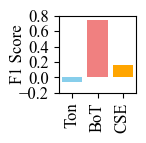

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
# É o F1 AVG da tabela 3 - F1 da Tabela 2
labels = ['Ton', 'BoT', 'CSE']
values = [0.79 - 0.85 , 0.91 - 0.17, 0.34 - 0.18]

# Criar o gráfico de barras
plt.figure(figsize=(1, 1)) # Retornando ao tamanho original

# Nota: A fonte é configurada globalmente na célula anterior (rcParams)

plt.bar(labels, values, color=['skyblue', 'lightcoral', 'orange'])

# Configurações de tamanho (a família da fonte vem do global)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Adicionar título e rótulos
plt.ylabel('F1 Score', labelpad=-5) # Ajustando o labelpad para aproximar o rótulo do eixo Y

plt.xticks(rotation=90) # Retornando à rotação original

# Definir os limites do eixo Y e os ticks
plt.ylim(-0.2, 0.8) # Define os limites do eixo Y
plt.yticks(np.arange(-0.2, 0.81, 0.2)) # Define os ticks com intervalo de 0.1

plt.savefig(LOG_DIR + 'ToN.pdf', bbox_inches='tight', transparent=True, pad_inches=0)

# Mostrar o gráfico
plt.show()

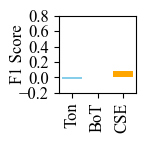

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
# É o F1 AVG da tabela 3 - F1 da Tabela 2
labels = ['Ton', 'BoT', 'CSE']
values = [0.59 - 0.61 , 0.98 - 0.98, 0.59 - 0.51]

# Criar o gráfico de barras
plt.figure(figsize=(1, 1)) # Retornando ao tamanho original

plt.bar(labels, values, color=['skyblue', 'lightcoral', 'orange'])

plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Adicionar título e rótulos
plt.ylabel('F1 Score', labelpad=-5) # Ajustando o labelpad para aproximar o rótulo do eixo Y

plt.xticks(rotation=90) # Retornando à rotação original

# Definir os limites do eixo Y e os ticks
plt.ylim(-0.2, 0.8) # Define os limites do eixo Y
plt.yticks(np.arange(-0.2, 0.81, 0.2)) # Define os ticks com intervalo de 0.1

plt.savefig(LOG_DIR + 'BoT.pdf', bbox_inches='tight', transparent=True, pad_inches=0)

# Mostrar o gráfico
plt.show()

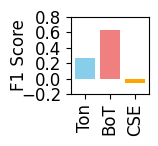

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
# É o F1 AVG da tabela 3 - F1 da Tabela 2
labels = ['Ton', 'BoT', 'CSE']
values = [0.63 - 0.36 , 0.89 - 0.26, 0.88 - 0.94]

# Criar o gráfico de barras
plt.figure(figsize=(1, 1)) # Retornando ao tamanho original

plt.bar(labels, values, color=['skyblue', 'lightcoral', 'orange'])

plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Adicionar título e rótulos
plt.ylabel('F1 Score', labelpad=-5) # Ajustando o labelpad para aproximar o rótulo do eixo Y

plt.xticks(rotation=90) # Retornando à rotação original

# Definir os limites do eixo Y e os ticks
plt.ylim(-0.2, 0.8) # Define os limites do eixo Y
plt.yticks(np.arange(-0.2, 0.81, 0.2)) # Define os ticks com intervalo de 0.1

plt.savefig(LOG_DIR + 'CSE.pdf', bbox_inches='tight', transparent=True, pad_inches=0)

# Mostrar o gráfico
plt.show()

In [ ]:
import pickle
import numpy as np
import pandas as pd

# Caminho do arquivo
#file_path = "checkpoint.pkl"

try:
    with open(LOG_DIR+'checkpoint_100.pkl', 'rb') as f:
        algorithm = pickle.load(f)

    print("--- STATUS DO CHECKPOINT ---")
    print(f"Geração Atual: {algorithm.n_gen}")
    print(f"Avaliações de Função Totais: {algorithm.evaluator.n_eval}")

    # Acessando as melhores soluções encontradas ATÉ AGORA (opt)
    best_solutions = algorithm.opt

    if best_solutions is None:
        print("Nenhuma solução ótima encontrada ainda (início da execução).")
    else:
        print(f"Soluções no Pareto Front atual: {len(best_solutions)}")

        data = []
        # O objeto 'opt' é uma lista de indivíduos. Precisamos iterar sobre eles.
        for i, ind in enumerate(best_solutions):

            # Genótipo (X)
            solucao = ind.X
            features_ativadas = np.sum(solucao[:-2] >= 0.5)
            qtd_neuronios = 2**int(solucao[-2])
            qtd_camadas = int(solucao[-1])

            # Fenótipo (F) - Objetivos
            # Lembra que salvamos 1 - F1, então precisamos inverter
            objs = ind.F
            f1_ds2 = 1 - objs[0]
            f1_ds3 = 1 - objs[1]
            f1_ds4 = 1 - objs[2]

            # Violação de Restrição (CV)
            cv = ind.CV[0] if isinstance(ind.CV, (list, np.ndarray)) else ind.CV

            data.append({
                "Solução ID": i,
                "Geração": algorithm.n_gen,
                "Qtd Features": features_ativadas,
                "Qtd Neurônios": qtd_neuronios,
                "Qtd Camadas": qtd_camadas,
                "F1 Score DS2": round(f1_ds2, 4),
                "F1 Score DS3": round(f1_ds3, 4),
                "F1 Score DS4": round(f1_ds4, 4),
                "Violação (CV)": cv
            })

        df_checkpoint = pd.DataFrame(data)

        print("\n--- Melhores soluções parciais (Top 5 por DS2) ---")
        # Filtra apenas soluções válidas (CV <= 0) e ordena
        validas = df_checkpoint[df_checkpoint["Violação (CV)"] <= 0]
        if not validas.empty:
            print(validas.sort_values(by="F1 Score DS2", ascending=False).head(5))
        else:
            print("Ainda não há soluções 100% viáveis (que atendem todas as restrições).")
            print("Mostrando as melhores inviáveis:")
            print(df_checkpoint.head(5))

except Exception as e:
    print(f"Erro ao ler o checkpoint: {e}")
    print("Verifique se o arquivo foi baixado completamente (não tem apenas 3KB).")

Erro ao ler o checkpoint: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-12-11 200/checkpoint_100.pkl'
Verifique se o arquivo foi baixado completamente (não tem apenas 3KB).


Então o arquivo final.pkl está corrompido, vou carregar do checkpoint

In [ ]:
import numpy as np
import pandas as pd

n_solutions = len(best_solutions)
print(f"Número de soluções encontradas (do checkpoint): {n_solutions}")
print("\nDetalhes para cada solução encontrada:")

#pega os indices dos melhores
idx_max_ds2 = -1
idx_max_ds3 = -1
idx_max_ds4 = -1
idx_max_avg = -1

vlr_max_ds2 = 0
vlr_max_ds3 = 0
vlr_max_ds4 = 0
vlr_max_avg = 0

vlr_avg_ds2 = 0;
vlr_avg_ds3 = 0;
vlr_avg_ds4 = 0;

for i, ind in enumerate(best_solutions):

    # Genótipo (X)
    solucao = ind.X
    features_ativadas = np.sum(solucao[:-2] >= 0.5)
    qtd_neuronios = 2**int(solucao[-2])
    qtd_camadas = int(solucao[-1])

    # Fenótipo (F) - Objetivos
    # Lembra que salvamos 1 - F1, então precisamos inverter
    objs = ind.F
    f1_ds2 = 1 - objs[0]
    f1_ds3 = 1 - objs[1]
    f1_ds4 = 1 - objs[2]

    # Violação de Restrição (CV)
    cv = ind.CV[0] if isinstance(ind.CV, (list, np.ndarray)) else ind.CV

    # Encontra os índices onde o valor é 1 (features selecionadas)
    selected_feature_indices = np.where(solucao[:-2] > 0.5)[0] # Use > 0.5 para acomodar floats

    # Mapeia os índices selecionados de volta para os nomes das features
    selected_features = [feature_names[j] for j in selected_feature_indices]

    print(f"Solução {i+1}:")
    print(f"  Geração: {algorithm.n_gen}")
    print(f"  Número de Neurônios: {qtd_neuronios}")
    print(f"  Quantidade de Features Selecionadas: {features_ativadas}")
    print(f"  Features Selecionadas: {selected_features}")
    print(f"  Número de camadas: {qtd_camadas}")
    print(f"  Objetivos (DS2, DS3, DS4): [{f1_ds2:.4f}, {f1_ds3:.4f}, {f1_ds4:.4f}]")
    print(f"  Soma dos Objetivos: {f1_ds2+f1_ds2+f1_ds2:.4f}")
    print(f"  Violação (CV): {cv}")
    print("-" * 20)

    #ds2
    if f1_ds2 > vlr_max_ds2:
        idx_max_ds2 = i
        vlr_max_ds2 = f1_ds2

    #ds3
    if f1_ds3 > vlr_max_ds3:
        idx_max_ds3 = i
        vlr_max_ds3 = f1_ds3

    #ds4
    if f1_ds4 > vlr_max_ds4:
        idx_max_ds4 = i
        vlr_max_ds4 = f1_ds4

    #avg
    current_avg = f1_ds2 + f1_ds3 + f1_ds4
    if current_avg > vlr_max_avg:
        idx_max_avg = i
        vlr_max_avg = current_avg
        vlr_avg_ds2 = f1_ds2
        vlr_avg_ds3 = f1_ds3
        vlr_avg_ds4 = f1_ds4

#Ao final, imprime os indices
print(f"Melhor F1 DS2:{vlr_max_ds2:.4f} na solução {idx_max_ds2+1} ")
print(f"Melhor F1 DS3:{vlr_max_ds3:.4f} na solução {idx_max_ds3+1} ")
print(f"Melhor F1 DS4:{vlr_max_ds4:.4f} na solução {idx_max_ds4+1} ")
print(f"Melhor F1 AVG:{vlr_max_avg:.4f}, média de {vlr_max_avg/3:.4f} na solução {idx_max_avg+1} | DS2:{vlr_avg_ds2:.4f} DS3:{vlr_avg_ds3:.4f} DS4:{vlr_avg_ds4:.4f} ")

NameError: name 'best_solutions' is not defined

### Gráfico paralelo

In [ ]:
import pickle

# Define o caminho do arquivo salvo
load_path = LOG_DIR+LOG_FINAL

# Carrega o objeto res_dt do arquivo
with open(load_path, 'rb') as f:
    loaded_res_dt = pickle.load(f)

print(f"Objeto res_dt carregado com sucesso de: {load_path}")

Objeto res_dt carregado com sucesso de: /content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-12-11 200/final.pkl


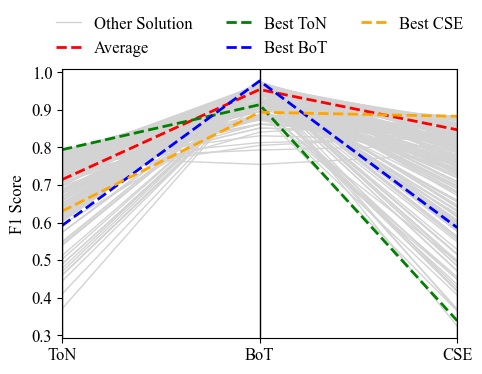

In [ ]:
# Extrai os objetivos do resultado carregado
# A variável 'best_solutions' já deve estar carregada do checkpoint anterior

# Lista para armazenar os objetivos (F1 scores) de cada solução
objectives_list = []

best_solutions = loaded_res_dt.F

# Itera sobre as melhores soluções do checkpoint para coletar os objetivos
for ind in best_solutions:
    # ind.F contém os valores dos objetivos (1-F1 DS2, 1-F1 DS3, 1-F1 DS4)
    objectives_list.append(ind)

# Converte os objetivos para um DataFrame pandas
df_solutions = pd.DataFrame(objectives_list, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])

# Calcula os valores de F1 score (1 - (1-F1))
df_solutions['ToN'] = 1 - df_solutions['1-F1 DS2']
df_solutions['BoT'] = 1 - df_solutions['1-F1 DS3']
df_solutions['CSE'] = 1 - df_solutions['1-F1 DS4']

# Calcula a média dos objetivos F1 score para todas as soluções
df_solutions['AVG'] = df_solutions['ToN'] + df_solutions['BoT'] + df_solutions['CSE']

# Marca como default todas as soluções para posterior desenho em cinza
df_solutions['Type'] = 'Other Solution'

# Encontra os índices das melhores soluções para cada critério
# Usamos .idxmax() para obter o índice do valor máximo
idx_best_avg = df_solutions['AVG'].idxmax()
idx_best_ton = df_solutions['ToN'].idxmax()
idx_best_bot = df_solutions['BoT'].idxmax()
idx_best_cse = df_solutions['CSE'].idxmax()

# Aplica os rótulos de 'Type' aos índices específicos
# Se uma solução for a melhor em várias categorias, a última atribuição prevalecerá
df_solutions.loc[idx_best_avg, 'Type'] = 'Average'
df_solutions.loc[idx_best_ton, 'Type'] = 'Best ToN'
df_solutions.loc[idx_best_bot, 'Type'] = 'Best BoT'
df_solutions.loc[idx_best_cse, 'Type'] = 'Best CSE'

# Inverte a ordem para que as linhas especiais (não 'Individual Solution') sejam desenhadas por último
# para que seus estilos sejam mais proeminentes. Isso é opcional.
df_solutions.sort_values(by='Type', key=lambda x: x.map({'Other Solution': 0, 'Average': 1, 'Best ToN': 2, 'Best BoT': 3, 'Best CSE': 4}), inplace=True)

# Define o mapeamento de cores
color_map = {
    'Other Solution': 'lightgray',
    'Average': 'red',
    'Best ToN': 'green',
    'Best BoT': 'blue',
    'Best CSE': 'orange'
}

# Cria o gráfico de Coordenadas Paralelas
plt.figure(figsize=(5, 4)) # Increased figure size
ax = pd.plotting.parallel_coordinates(df_solutions,
                                      class_column='Type',
                                      cols=['ToN', 'BoT', 'CSE'],
                                      color=[color_map[c] for c in df_solutions['Type'].unique() if c in color_map],
                                      alpha=1) # Keep alpha=1 for all lines initially

# Configurações de fonte (assumindo global já definido)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Aplica a largura e estilo da linha personalizados com base no 'Type'
for line in ax.get_lines():
    label = line.get_label()
    if label in ['Average', 'Best ToN', 'Best BoT', 'Best CSE' ]:
        line.set_linewidth(2)
        line.set_linestyle('--')
    else:
        line.set_linewidth(1)
        line.set_linestyle('-')

plt.ylabel('F1 Score')

plt.grid(False)
# Ajusta a posição da legenda
legend_handles, legend_labels = ax.get_legend_handles_labels()
filtered_handles_labels = [(h, l) for h, l in zip(legend_handles, legend_labels) if l in df_solutions['Type'].unique()]
ax.legend([h for h, _ in filtered_handles_labels], [l for _, l in filtered_handles_labels],
          bbox_to_anchor=(0.5, 1.25), loc='upper center', ncol=3, frameon=False, handlelength=1.5)

plt.tight_layout()

# Salva o gráfico em PDF
plt.savefig(LOG_DIR + 'parallel_coordinates_plot.pdf', bbox_inches='tight',
            transparent=True, pad_inches=0)
plt.show()